In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
df=pd.read_csv("insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


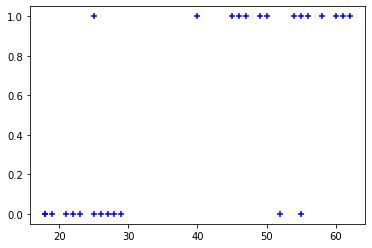

In [3]:
plt.scatter(df.age, df.bought_insurance, marker='+', color='blue')

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
X_train, X_test, y_train, y_test = train_test_split(df[['age']], df.bought_insurance, test_size=0.1)
scaler=StandardScaler()

In [6]:
X_test

,age
22,40
12,27
7,60


In [7]:
from sklearn.linear_model import LogisticRegression

In [8]:
model=LogisticRegression()

In [9]:
model.fit(X_train, y_train)

LogisticRegression()

In [10]:
model.predict(X_test)

array([1, 0, 1], dtype=int64)

In [11]:
model.score(X_test, y_test)

1.0

In [12]:
model.predict_proba(X_test)

array([[0.49249276, 0.50750724],
       [0.83885526, 0.16114474],
       [0.06822455, 0.93177545]])

In [13]:
model.predict([[60]])

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

#### Logistic Regression from Scratch

In [14]:
def sigmoid(z):
    return 1.0/(1.0 + np.exp(-z))

In [15]:
def calculate_gradient(theta, X, y):
    m=y.size   #number of instances
    return X.T @ (sigmoid(X@theta) - y) / m

In [16]:
def gradient_descent(X, y, alpha=0.1, num_iter=100, tol=1e-7):
    X_b=np.c_[np.ones((X.shape[0], 1)), X]
    theta=np.zeros(X_b.shape[1])
    
    for i in range(num_iter):
        grad = calculate_gradient(theta, X_b, y)
        theta -= alpha*grad
        
        if np.linalg.norm(grad) < tol:
            break
    return theta

In [17]:
def predict_proba(X, theta):
    X_b=np.c_[np.ones((X.shape[0], 1)), X]
    return sigmoid(X_b @ theta)

In [18]:
def predict(X, theta, threshold=0.5):
    return (predict_proba(X, theta) >= threshold).astype(int)

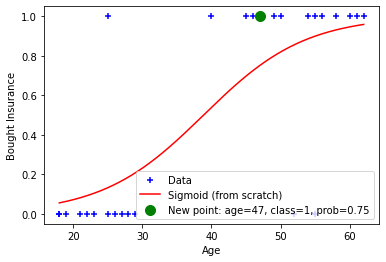

In [19]:
age_scaler = StandardScaler()
X_age_scaled = age_scaler.fit_transform(df[['age']].values)
y_age = df.bought_insurance.values

theta_age = gradient_descent(X_age_scaled, y_age, alpha=0.1, num_iter=1000)

x_vals = np.linspace(df.age.min(), df.age.max(), 300).reshape(-1, 1)
x_vals_scaled = age_scaler.transform(x_vals)
y_vals = predict_proba(x_vals_scaled, theta_age)

random_age = np.array([[np.random.randint(df.age.min(), df.age.max())]])
random_age_scaled = age_scaler.transform(random_age)
random_class = predict(random_age_scaled, theta_age)[0]
random_prob = predict_proba(random_age_scaled, theta_age)[0]

plt.scatter(df.age, df.bought_insurance, marker='+', color='blue', label='Data')
plt.plot(x_vals, y_vals, color='red', label='Sigmoid (from scratch)')
plt.scatter(random_age, random_class, color='green', s=100, zorder=5,
            label=f'New point: age={random_age[0][0]}, class={random_class}, prob={random_prob:.2f}')
plt.xlabel('Age')
plt.ylabel('Bought Insurance')
plt.legend()
plt.show()

In [20]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [21]:
X,y=load_breast_cancer(return_X_y = True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler=StandardScaler()

In [22]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

theta_hat = gradient_descent(X_train_scaled, y_train, alpha=0.1)

y_pred_train = predict(X_train_scaled, theta_hat)
y_pred_test = predict(X_test_scaled, theta_hat)

In [23]:
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(train_acc)
print(test_acc)

0.9802197802197802
0.9912280701754386


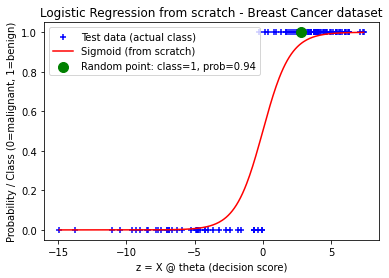

In [24]:
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]
z_test = X_test_b @ theta_hat

z_line = np.linspace(z_test.min(), z_test.max(), 300)
prob_line = sigmoid(z_line)

random_idx = np.random.randint(0, X_test_scaled.shape[0])
random_z = z_test[random_idx]
random_prob = sigmoid(random_z)
random_class = int(random_prob >= 0.5)

plt.scatter(z_test, y_test, marker='+', color='blue', label='Test data (actual class)')
plt.plot(z_line, prob_line, color='red', label='Sigmoid (from scratch)')
plt.scatter(random_z, random_class, color='green', s=100, zorder=5,
            label=f'Random point: class={random_class}, prob={random_prob:.2f}')
plt.xlabel('z = X @ theta (decision score)')
plt.ylabel('Probability / Class (0=malignant, 1=benign)')
plt.title('Logistic Regression from scratch - Breast Cancer dataset')
plt.legend()
plt.show()